# Protenix V1 RNA Raw Inference

This notebook builds Protenix inputs directly from raw RNA sequence CSVs such as
`validation_sequences.csv` or `test_sequences.csv`.

It does not depend on the validation label cache for inference. It still needs the
Protenix CCD cache because the model featurizer uses the chemical component definitions
in `components.cif` plus the matching `.rdkit_mol.pkl` cache.

If the RDKit pickle is missing but the CCD CIF exists, this notebook can generate the
pickle on the fly before loading the model.


In [29]:
pwd


'/scratch/work/sethih1/RNA-prediction/sin-Stanford-RNA-3D-Folding-2/kaggle-new-solution/notebooks'

In [30]:
from pathlib import Path
import sys

import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

code_dir_candidates = [
    (Path.cwd().parent / "code").resolve(),
    (Path.cwd() / "kaggle-new-solution" / "code").resolve(),
]
CODE_DIR = next(path for path in code_dir_candidates if path.exists())
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import protenix_v1_rna_raw_inference_helpers as helpers

helpers.configure_notebook_logging()


In [31]:
PROTENIX_REPO = None
RNA_DATA_DIR = None
SEQUENCES_CSV = None
DATA_SPLIT = "validation"  # "validation", "test", or "train"

CHECKPOINT_PATH = None
CHECKPOINT_PATH = None #"/scratch/phys/sin/rna-dataset/models/1499_ema_0.995.pt"

CCD_ROOT = None
MSA_ROOT = None

USE_MSA = False
USE_RNA_MSA = True
BUILD_CCD_CACHE_IF_NEEDED = True
DOWNLOAD_CCD_IF_MISSING = False
CCD_CACHE_NUM_CPU = 4

N_EXAMPLES = 1
TARGET_IDS = None #['9JGM'] # ['9MME'] #['9JGM'] #None
CROP_SIZE = None

MODEL_NAME = "protenix_base_default_v1.0.0"
DIFFUSION_SAMPLES = 1
DIFFUSION_STEPS = 20
MC_DROPOUT_APPLY_RATE = 0.0

OUTPUT_DIR = (Path("../notebooks_output/protenix_v1_rna_raw_inference")).resolve()


In [32]:
checkpoint_df = helpers.discover_checkpoints(PROTENIX_REPO)
selected_checkpoint = helpers.choose_checkpoint(CHECKPOINT_PATH, checkpoint_df)

data_dir, sequences_df, sequences_csv = helpers.load_sequences_table(
    data_dir=RNA_DATA_DIR,
    sequences_csv=SEQUENCES_CSV,
    split=DATA_SPLIT,
)
selected_rows = helpers.select_sequence_rows(
    sequences_df,
    target_ids=TARGET_IDS,
    n_examples=N_EXAMPLES,
)
ccd_info = helpers.ensure_ccd_cache(
    ccd_root=CCD_ROOT,
    protenix_repo=PROTENIX_REPO,
    build_if_needed=BUILD_CCD_CACHE_IF_NEEDED,
    download_if_missing=DOWNLOAD_CCD_IF_MISSING,
    num_cpu=CCD_CACHE_NUM_CPU,
)

display_rows = selected_rows.copy()
display_rows["length"] = display_rows["sequence"].astype(str).str.len()

print(f"Sequences CSV: {sequences_csv}")
print(f"Data dir: {data_dir}")
print(f"Selected checkpoint: {selected_checkpoint}")
print(f"CCD root: {ccd_info['ccd_root']}")
print(f"CCD components file: {ccd_info['components_file']}")
print(f"CCD rdkit pickle: {ccd_info['rdkit_pkl']}")
print(f"CCD status: {ccd_info['status']}")

display(checkpoint_df.head(20))
display(display_rows)


Sequences CSV: /scratch/phys/sin/rna-dataset/validation_sequences.csv
Data dir: /scratch/phys/sin/rna-dataset
Selected checkpoint: /scratch/phys/sin/rna-dataset/models/1799_ema_0.995.pt
CCD root: /scratch/phys/sin/rna-dataset/protenix_ccd_cache
CCD components file: /scratch/phys/sin/rna-dataset/protenix_ccd_cache/components.v20240608.cif
CCD rdkit pickle: /scratch/phys/sin/rna-dataset/protenix_ccd_cache/components.v20240608.cif.rdkit_mol.pkl
CCD status: existing_rdkit_cache


,source,path,filename,parent,is_ema,step,size_mb,mtime,source_rank
0,official_train_dir,/scratch/phys/sin/rna-dataset/models/1799_ema_...,1799_ema_0.995.pt,models,True,1799,4222.36,2026-03-25 13:17:46,0
1,official_train_dir,/scratch/phys/sin/rna-dataset/models/1699_ema_...,1699_ema_0.995.pt,models,True,1699,4222.36,2026-03-25 11:09:21,0
2,official_train_dir,/scratch/phys/sin/rna-dataset/models/1599_ema_...,1599_ema_0.995.pt,models,True,1599,4222.36,2026-03-25 09:04:01,0
3,official_train_dir,/scratch/phys/sin/rna-dataset/models/1499_ema_...,1499_ema_0.995.pt,models,True,1499,4222.36,2026-03-25 06:57:08,0
4,official_train_dir,/scratch/phys/sin/rna-dataset/models/1399_ema_...,1399_ema_0.995.pt,models,True,1399,4222.36,2026-03-25 04:50:23,0
5,official_train_dir,/scratch/phys/sin/rna-dataset/models/1299_ema_...,1299_ema_0.995.pt,models,True,1299,4222.36,2026-03-25 02:45:20,0
6,official_train_dir,/scratch/phys/sin/rna-dataset/models/1199_ema_...,1199_ema_0.995.pt,models,True,1199,4222.36,2026-03-25 00:38:22,0
7,official_train_dir,/scratch/phys/sin/rna-dataset/models/1099_ema_...,1099_ema_0.995.pt,models,True,1099,4222.36,2026-03-24 22:33:26,0
8,official_train_dir,/scratch/phys/sin/rna-dataset/models/999_ema_0...,999_ema_0.995.pt,models,True,999,4222.35,2026-03-24 20:27:06,0
9,official_train_dir,/scratch/phys/sin/rna-dataset/models/899_ema_0...,899_ema_0.995.pt,models,True,899,4222.35,2026-03-24 18:20:48,0


,target_id,sequence,temporal_cutoff,description,stoichiometry,all_sequences,ligand_ids,ligand_SMILES,length
0,8ZNQ,ACCGUGACGGGCCUUUUGGCUAUACGCGGU,2025-06-04,Solution structure of the complex of naphthyri...,A:1,>8ZNQ_1|Chain A[auth A]|RNA (30-MER)|\nACCGUGA...,NAZ,Cc1ccc2ccc(nc2n1)NC(=O)CCNCCC(=O)NCc3ccc4c(n3)...,30


In [33]:
runner, runner_configs = helpers.load_runner(
    checkpoint_path=selected_checkpoint,
    ccd_root=ccd_info["ccd_root"],
    protenix_repo=PROTENIX_REPO,
    build_ccd_cache_if_needed=False,
    model_name=MODEL_NAME,
    dtype="bf16",
    use_msa=USE_MSA,
    use_rna_msa=USE_RNA_MSA,
    n_diffusion_samples=DIFFUSION_SAMPLES,
    n_diffusion_steps=DIFFUSION_STEPS,
    mc_dropout_apply_rate=MC_DROPOUT_APPLY_RATE,
    output_dir=OUTPUT_DIR,
)


2026-03-25 15:15:32,371 INFO runner.inference: Distributed environment: world size: 1, global rank: 0, local rank: 0
2026-03-25 15:15:32,410 INFO root: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-e031eb42-b078-555e-9355-1985f73e15dc]
2026-03-25 15:15:32,453 INFO root: Finished environment initialization.


train scheduler 16.0
inference scheduler 16.0
Diffusion Module has 16.0


In [34]:
bundles = helpers.prepare_raw_examples(
    selected_rows,
    msa_root=MSA_ROOT,
    protenix_repo=PROTENIX_REPO,
    use_msa=USE_MSA,
    use_rna_msa=USE_RNA_MSA,
    crop_size=CROP_SIZE,
)

bundle_overview = pd.DataFrame(
    [
        {
            "target_id": bundle["target_id"],
            "length": len(bundle["sequence"]),
            "n_token": bundle["n_token"],
            "used_msa": bundle["used_msa"],
            "msa_path": bundle["msa_path"],
            "was_cropped": bundle["was_cropped"],
        }
        for bundle in bundles
    ]
)
display(bundle_overview)


2026-03-25 15:16:16,614 INFO protenix.data.constraint.constraint_featurizer: Loaded constraint feature: #atom contact:0 #contact:0 #pocket:0


,target_id,length,n_token,used_msa,msa_path,was_cropped
0,8ZNQ,30,30,False,None,False


In [35]:
results = helpers.run_raw_inference(runner, bundles)
summary_df = helpers.summarize_raw_results(results)
display(summary_df)

best_per_target = (
    summary_df
    .sort_values(["target_id", "ranking_score", "plddt"], ascending=[True, False, False])
    .groupby("target_id", as_index=False)
    .first()
)
display(best_per_target)


Raw RNA inference:   0%|          | 0/1 [00:00<?, ?it/s]

,target_id,prediction_index,ranking_score,plddt,has_clash,num_recycles,ptm,iptm,gpde,disorder
0,8ZNQ,0,0.076008,71.668098,False,10,0.380039,0.0,1.350947,0.0


,target_id,prediction_index,ranking_score,plddt,has_clash,num_recycles,ptm,iptm,gpde,disorder
0,8ZNQ,0,0.076008,71.668098,False,10,0.380039,0.0,1.350947,0.0


,prediction_index,ranking_score,plddt,has_clash,num_recycles,ptm,iptm,gpde,disorder
0,0,0.076008,71.668098,False,10,0.380039,0.0,1.350947,0.0


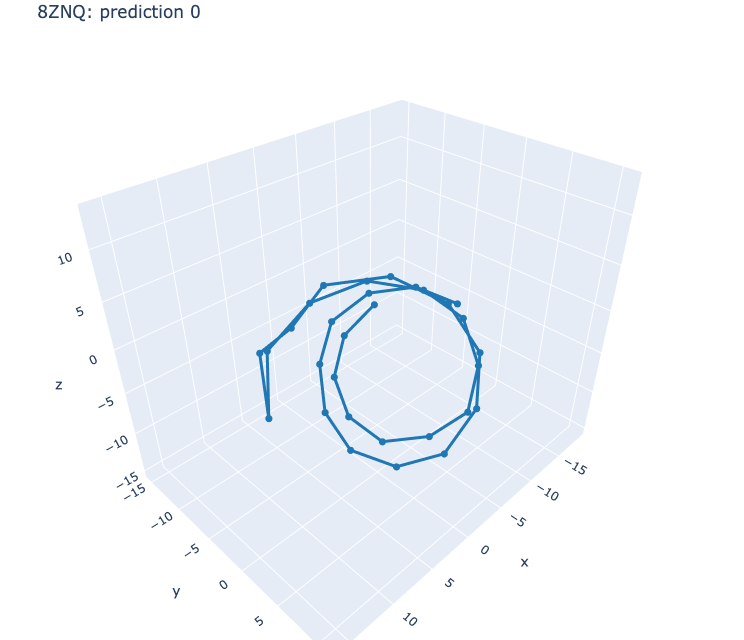

In [36]:
TARGET_TO_PLOT = selected_rows.iloc[0]["target_id"]
PREDICTION_ROW = 0

result = helpers.get_result(results, TARGET_TO_PLOT)
display(result["metrics"])

pred_coords, pred_idx = helpers.get_prediction_c1_trace(
    result,
    prediction_row=PREDICTION_ROW,
)
helpers.plot_rna_3d_interactive(
    pred_coords,
    title=f"{TARGET_TO_PLOT}: prediction {pred_idx}",
)


In [37]:
predictions_dir = helpers.save_prediction_artifacts(result, OUTPUT_DIR)
print(f"Saved prediction files to: {predictions_dir}")


Saved prediction files to: /scratch/work/sethih1/RNA-prediction/sin-Stanford-RNA-3D-Folding-2/kaggle-new-solution/notebooks_output/protenix_v1_rna_raw_inference/8ZNQ/seed_101/predictions


In [38]:
print(
    "This notebook is raw-data inference only. "
    "For RMSD and overlay against validation ground truth, use "
    "protenix_v1_rna_validation_inference.ipynb."
)


This notebook is raw-data inference only. For RMSD and overlay against validation ground truth, use protenix_v1_rna_validation_inference.ipynb.
